# PEER+TEXT on held-out dataset E — gold-free NL→FOL faithfulness scoring

This notebook is a runnable walk-through of `method.py`, the end-to-end driver of the experiment **"Peer agreement plus text checks, held-out test"**.

**Setting.** You get a sentence and a candidate first-order-logic (FOL) formula from some system, and **no gold formula**. The goal is a score that predicts whether the formula is *faithful* to the sentence.

**Method (PEER+TEXT).**
* **PEER**: graded agreement across model families. The sentence is formalised by peer models from *other* families. Each peer formula is aligned into the candidate's vocabulary. The candidate is split into claim units, and each unit is checked against the peers with a finite-model refuter plus z3 entailment. This gives `support`, `coverage`, `g_score`, plus unit error codes.
* **TEXT**: text-only checks from iteration 1. `l2_bow` does content accounting between the sentence and the formula. `l3_z3` answers a text-only questionnaire and compares it with the formula's z3 role profile.
* **Fusion**: a logistic model fitted and **frozen on the iteration-1 screen** (prereg sha256 `b9f28b1b…`) and then scored **once** on the held-out set E (8,507 candidate rows, 700 sentences).

**Baselines on the same rows:** a cheap LLM judge (gemini-2.5-flash-lite; the API key ran out, so it could not be tested), a local Qwen3-8B judge (a secondary, labelled bar), the iteration-1 binary consensus `c_score_align`, name-free consensus, `l2_bow`, `l3`, L1 lint, and L2-role.

**Headline (full E, tiers A+B, 1822 errors / 864 correct):** PEER+TEXT AUROC **0.790** [0.75, 0.82], compared with the local judge at 0.712 (Δ +0.078, CI > 0), TEXT alone at 0.693, and `c_score_align` alone at 0.782. The fusion does **not** beat `c_score_align` alone.

**What this demo runs.** The expensive stages (`views`, `api` for OpenRouter LLM calls, `local` for the GPU judge, `screen`, `score` for solver runs, `analyse`) need API keys, a GPU and hours of solver time. Their outputs are shipped precomputed in `mini_demo_data.json`: a curated 100-row subset of E with every per-item score, its labels, and the frozen analysis/prereg results. The notebook runs the original driver's **`outputs` stage** (`build_outputs`) on that subset. It then re-applies the frozen fusion to show where `p_peer_text` comes from, and visualises the results.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT on Colab, always install
_pip('loguru==0.7.3')

# numpy, pandas, sklearn, matplotlib — pre-installed on Colab, install locally only
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.6.1', 'matplotlib==3.10.0')

## Imports
The original `method.py` import block, followed by the extra imports this notebook uses for the fusion check and the plots.

In [2]:
from __future__ import annotations

import json
import subprocess
import sys
from pathlib import Path

from loguru import logger

# --- notebook additions (fusion re-check + visualisation) ---
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

## Load the demo data
`mini_demo_data.json` is loaded from the GitHub repo, with a fallback to a local copy. It holds:
* `per_item_E`: the per-row score records written by the `score` stage (`results/per_item_E.jsonl` in the original workspace);
* `E_labels`: the label view, with solver/adjudicated `final_label` and `label_tier` (`data/E_labels.jsonl`);
* `E_blind`: the blind view, with sentence text and candidate FOL (`data/E_blind.jsonl`);
* `analysis`, `prereg`, `p_tests`, `prereg_sha256`: the frozen full-E results the driver copies into its output metadata.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-eff060-layered-gold-free-checks-for-logic/fork/run_An1uy2kF2SjZ/round-2/experiment-5/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["description"])
print({k: (len(v) if isinstance(v, (list, dict)) else type(v).__name__) for k, v in data.items()})

Curated 100-row subset of held-out dataset E (NL->FOL candidates, gold-free faithfulness scores + solver/adjudicated labels) for the PEER+TEXT demo. per_item_E = every metric score per row; E_labels = label view (joined only after scoring); E_blind = blind view (text + candidate FOL); analysis/prereg/p_tests = frozen full-E results.
{'description': 'str', 'per_item_E': 100, 'E_labels': 100, 'E_blind': 100, 'analysis': 2, 'prereg': 3, 'p_tests': 6, 'prereg_sha256': 'str'}


## Config
* `N_ROWS`: how many rows of the curated subset go through `build_outputs`. The subset has 100 rows: 40 ERROR and 40 CORRECT from tiers A/B, balanced over the strata L25/L20/EXC/CTRL, plus 20 unparseable, tier-C, contested or unresolved rows. The rows are interleaved, so any prefix mixes classes. The original run used **all 8,507 rows of E**.
* `STAGE`: the stage that `main()` runs. The original default is `"all"`, which reruns every stage. Only `"outputs"` can run inside this notebook; the other stages need the original `src/` scripts, API keys and a GPU.

In [5]:
N_ROWS = 100          # original: all 8507 rows of dataset E
STAGE = "outputs"     # original: sys.argv[1] if given, else "all" (views, api, local, screen, score, analyse, outputs)

## Driver setup and helpers
This is the original module header. In the notebook, `ROOT` is the current directory instead of `Path(__file__).resolve().parent`, because a notebook has no `__file__`. `PY` and `PY_GPU` point to the virtual environments the subprocess stages ran in. `sh` runs one stage, `jl` reads JSONL, and `s` formats a score as a string (`"NA"` for missing).

In [6]:
ROOT = Path.cwd()  # original: Path(__file__).resolve().parent
PY = str(ROOT / ".venv" / "bin" / "python")
PY_GPU = str(ROOT / ".venv_gpu" / "bin" / "python")

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
logger.add(ROOT / "logs" / "method.log", rotation="30 MB", level="DEBUG")


def sh(args: list[str]) -> None:
    logger.info("$ " + " ".join(args))
    r = subprocess.run(args, cwd=ROOT)
    if r.returncode != 0:
        raise RuntimeError(f"stage failed ({r.returncode}): {' '.join(args)}")


def jl(p: Path) -> list[dict]:
    return [json.loads(l) for l in p.read_text().splitlines() if l.strip()] if p.exists() else []


def s(x) -> str:
    if x is None:
        return "NA"
    if isinstance(x, float):
        return f"{x:.6f}"
    return str(x)

## Where the scores come from: the frozen PEER+TEXT fusion
The `score` stage (`src/score_E.py`) computed `p_peer_text` for each row with `fused_score` from `src/peer_text.py`. The code below is copied verbatim from there.
* Standardise each feature with the screen mean and sd. A missing feature gets z = 0.
* Apply the frozen logistic. Its features are `ALIGN:g_score` (the PEER graded score), `c_score_align`, `l2_bow` and `l3_z3`.
* If peers are unavailable, fall back to the pre-registered TEXT-only model (`l2_bow`, `l3_z3`).
* An unparseable candidate gets p_error = 1.

We re-apply it to the stored per-item features to check that it reproduces the shipped `p_peer_text` exactly. This check is not part of `method.py`; it only shows what the score is.

In [7]:
# ---- copied from src/peer_text.py (fusion section) ----
def _z(x, mu, sd):
    return 0.0 if x is None else (x - mu) / (sd if sd > 0 else 1.0)


def apply_logistic(model: dict, feats: dict) -> float:
    """model = {'features', 'mean', 'sd', 'coef', 'intercept'}; missing feature -> z = 0."""
    s = model["intercept"]
    for f, m, sd, c in zip(model["features"], model["mean"], model["sd"], model["coef"]):
        s += c * _z(feats.get(f), m, sd)
    return 1 / (1 + math.exp(-s))


def fused_score(frozen: dict, feats: dict) -> dict:
    """Frozen PEER+TEXT fusion. Unparseable -> p_error 1.0. peer_unavailable -> frozen TEXT-only model (pre-registered).
    fired_signal = argmax standardized contribution (PEER = g/c_score_nf features, TEXT = l2_bow/l3)."""
    if feats.get("coverage_status") == "UNPARSEABLE":
        return {"p_error": 1.0, "flag": 1, "fired_signal": "UNPARSEABLE", "model_used": "none"}
    main = frozen["fusion"]
    use = main
    if feats.get("peer_unavailable") or feats.get(main["features"][0]) is None:
        use = frozen["text_only"]
    p = apply_logistic(use, feats)
    contrib = {f: c * _z(feats.get(f), m, sd) for f, m, sd, c in zip(use["features"], use["mean"], use["sd"], use["coef"])}
    top = max(contrib, key=contrib.get) if contrib else None
    sig = "PEER" if top in ("g_score", "c_score_nf", "c_score_align") else ("TEXT" if top else None)
    thr = main["threshold"] if use is main else frozen["text_only"]["threshold"]
    return {"p_error": p, "flag": int(p >= thr), "fired_signal": sig, "model_used": "fusion" if use is main else "text_only"}


# ---- notebook check: recompute p_peer_text for the demo rows from the stored features ----
frozen = data["prereg"]["frozen"]
print("frozen fusion features:", frozen["fusion"]["features"], "coef:", [round(c, 3) for c in frozen["fusion"]["coef"]],
      "threshold:", round(frozen["fusion"]["threshold"], 3))
max_diff = 0.0
for r in data["per_item_E"][:N_ROWS]:
    feats = dict(r, **{"ALIGN:g_score": r["g_score"]})  # the per-item record stores ALIGN:g_score as g_score
    fs = fused_score(frozen, feats)
    max_diff = max(max_diff, abs(fs["p_error"] - r["p_peer_text"]))
print(f"max |recomputed - stored p_peer_text| over {min(N_ROWS, len(data['per_item_E']))} rows: {max_diff:.2e}")

frozen fusion features: ['ALIGN:g_score', 'c_score_align', 'l2_bow', 'l3_z3'] coef: [-0.116, 1.746, 3.087, 0.845] threshold: 0.69
max |recomputed - stored p_peer_text| over 100 rows: 0.00e+00


## `build_outputs`: join scores, blind view and labels into `method_out.json`
This is the original function. It writes one `exp_gen_sol_out` example per E row:
* the input is the blind view: text, candidate FOL, system, prompt variant;
* the output is the E `final_label`, joined only *after* the analysis;
* each metric's score goes into a `predict_*` field, oriented so that higher = more likely an error;
* the metadata carries strata, label tier, unit error codes, cost and time.

The only change is that the inputs come from the loaded `data` dict instead of the files under `results/` and `data/` (the original file paths are kept in comments). The rows are also limited to `N_ROWS`.

In [8]:
def build_outputs() -> None:
    """method_out.json in the exp_gen_sol_out schema: one example per E row (input = blind-view JSON, output = the E
    final label joined AFTER the analysis), predict_* = every metric's score (higher = more likely an error)."""
    items = data["per_item_E"][:N_ROWS]                           # jl(ROOT / "results" / "per_item_E.jsonl")
    labels = {r["row_key"]: r for r in data["E_labels"]}          # jl(ROOT / "data" / "E_labels.jsonl")
    blind = {r["row_key"]: r for r in data["E_blind"]}            # jl(ROOT / "data" / "E_blind.jsonl")
    analysis = data["analysis"]                                   # ROOT / "results" / "analysis.json"
    pre = data["prereg"]                                          # ROOT / "results" / "prereg.json"
    ex = []
    for r in items:
        b = blind[r["row_key"]]
        L = labels[r["row_key"]]
        inp = {"text": b["text"], "candidate_fol": b["candidate_fol"], "system": b["system"], "prompt_variant": b["prompt_variant"],
               "row_key": r["row_key"], "item_id": b["item_id"], "sentence_id": b["sentence_id"]}
        e = {"input": json.dumps(inp, ensure_ascii=False), "output": L["final_label"],
             "predict_peer_text": s(r.get("p_peer_text")), "predict_peer_text_flag": s(r.get("flag")),
             "predict_peer": s(r.get("peer_only")), "predict_text": s(r.get("p_text")),
             "predict_g_score": s(r.get("g_score")), "predict_c_score_nf": s(r.get("c_score_nf")),
             "predict_c_score_align": s(r.get("c_score_align")), "predict_nf_g_score": s(r.get("nf_g_score")),
             "predict_nf_c_score": s(r.get("nf_c_score")), "predict_l2_bow": s(r.get("l2_bow")), "predict_l3": s(r.get("l3_z3")),
             "predict_l1_any": s(r.get("l1_any")), "predict_l2_role": s(r.get("l2_role")),
             "predict_judge_cheap_disg": s(r.get("judge_cheap_disg")), "predict_judge_cheap_orig": s(r.get("judge_cheap_orig")),
             "predict_judge_local_qwen8b_disg": s(r.get("judge_local_qwen8b_disg")),
             "predict_judge_local_qwen8b_orig": s(r.get("judge_local_qwen8b_orig")),
             "metadata_row_key": r["row_key"], "metadata_item_id": r["item_id"], "metadata_sentence_id": r["sentence_id"],
             "metadata_system": r["system"], "metadata_system_class": r["system_class"], "metadata_family_vendor": r["family_vendor"],
             "metadata_stratum": r["stratum"], "metadata_strata": r["strata"], "metadata_fold_E": r["fold_E"],
             "metadata_label_tier": L["label_tier"], "metadata_repair_ops": L["repair_ops"], "metadata_error_ops": L["error_ops"],
             "metadata_reading_choice": L["reading_choice"], "metadata_coverage_status": r["coverage_status"],
             "metadata_unit_codes": [c["code"] + ":" + c.get("unit", "")[:120] for c in (r.get("unit_codes") or [])][:12],
             "metadata_top_code": r.get("top_code"), "metadata_fired_signal": r.get("fired_signal"),
             "metadata_model_used": r.get("model_used"), "metadata_n_unknown": r.get("n_unknown"),
             "metadata_n_peers_used": r.get("n_peers_used"), "metadata_peer_unavailable": r.get("peer_unavailable"),
             "metadata_support": r.get("support"), "metadata_coverage": r.get("coverage"),
             "metadata_medoid_ops": r.get("medoid_ops"), "metadata_judge_local_type": r.get("judge_local_qwen8b_disg_type"),
             "metadata_cost_usd": (r.get("cost_usd_peer_text") or 0.0), "metadata_judge_cost_usd": r.get("judge_cost_usd"),
             "metadata_secs": (r.get("secs_pairs") or 0.0) + (r.get("secs_text") or 0.0),
             "metadata_prereg_sha256": r["prereg_sha256"]}
        ex.append(e)
    heads = {k: {kk: vv for kk, vv in v.items() if kk in ("n", "n_error", "n_correct", "metrics")} for k, v in analysis["a_tables"].items()}
    out = {"metadata": {
        "method_name": "PEER+TEXT (graded cross-family consensus fused with solver-exact text checks), frozen on the screen, scored once on E",
        "prereg_sha256": data["prereg_sha256"].split()[0],       # (ROOT / "results" / "prereg.sha256").read_text()
        "peer_variant": pre["variant"], "F1_failed_on_screen": pre["selection_evidence"]["F1_failed"],
        "fusion": pre["frozen"]["fusion"], "text_only": pre["frozen"]["text_only"],
        "orientation": "every predict_* is oriented so that higher = more likely an error; NA = not available",
        "headline_auroc_tables": heads, "criteria": analysis["criteria"],
        "p_tests": data["p_tests"],                               # json.loads((ROOT / "results" / "p_tests.json").read_text())
        "workspace": str(ROOT)},
        "datasets": [{"dataset": "E_heldout_candidates", "examples": ex}]}
    (ROOT / "method_out.json").write_text(json.dumps(out, ensure_ascii=False))
    logger.info(f"method_out.json: {len(ex)} examples, {(ROOT / 'method_out.json').stat().st_size / 1e6:.1f} MB")

## `main`: the stage dispatcher
This is the original dispatcher. Each stage runs one script from `src/` as a subprocess. Every stage is resumable and cached. `STAGE` from the config cell replaces `sys.argv[1]`. With `STAGE = "outputs"`, only `build_outputs()` runs here. The other branches are kept as-is so the full pipeline is documented, but they need the original repository's `src/` scripts and environments.

In [9]:
@logger.catch(reraise=True)
def main():
    stage = STAGE  # original: sys.argv[1] if len(sys.argv) > 1 else "all"
    if stage in ("views", "all"):
        sh([PY, "src/data_views.py"])
    if stage in ("api", "all"):
        sh([PY, "src/run_api_E.py"])
    if stage in ("local", "all") and Path(PY_GPU).exists():
        sh([PY_GPU, "src/local_judge_E.py"])
    if stage in ("screen", "all"):
        if not (ROOT / "results" / "prereg.json").exists():
            sh([PY, "src/screen_fit.py", "compute"])
            sh([PY, "src/screen_fit.py", "fit"])
            sh([PY, "src/screen_fit.py", "freeze"])
    if stage in ("score", "all"):
        for st in ("mini", "100", "all"):
            sh([PY, "src/score_E.py", "run", "--stage", st])
        sh([PY, "src/score_E.py", "assemble"])
    if stage in ("analyse", "all"):
        sh([PY, "src/analyse_E.py"])
    if stage in ("outputs", "all"):
        build_outputs()


main()

16:14:57|INFO   |method_out.json: 100 examples, 0.3 MB


## Results
**Left:** the frozen headline AUROCs on the **full** held-out set E (R_AB pooled: tiers A+B, 1,822 errors / 864 correct), with bootstrap 95% CIs, as recorded in `analysis.json`.
**Right:** the same metrics recomputed from the `predict_*` fields of the `method_out.json` just built, on the demo rows labelled ERROR/CORRECT in tiers A/B. This is a small balanced subset, so expect noisy numbers. `NA` scores are imputed with the metric's median on the subset. The full analysis uses a screen-fitted neutral value instead.

The tables then show example rows and the pre-registered test outcomes.

Full E, R_AB pooled: n=2686 (errors=1822, correct=864)
                      metric  auroc  ci_lo  ci_hi  auprc
           PEER+TEXT (fused)  0.790  0.752  0.823  0.879
      c_score_align (iter-1)  0.782  0.744  0.818  0.861
         PEER only (g_score)  0.748  0.706  0.786  0.824
                  c_score_nf  0.746  0.705  0.784  0.828
                      L2-bow  0.734  0.706  0.762  0.830
local Qwen3-8B judge (disg.)  0.712  0.673  0.747  0.816
                   TEXT only  0.693  0.652  0.732  0.812
local Qwen3-8B judge (orig.)  0.648  0.603  0.691  0.781
                       L3 z3  0.579  0.529  0.625  0.720

Other frozen headline slices (PEER+TEXT vs c_score_align vs local judge):
  R_AB long (L25+L20+EXC)    p_peer_text=0.768  c_score_align=0.759  judge_local_qwen8b_disg=0.653
  R_A pooled L20+EXC         p_peer_text=0.818  c_score_align=0.860  judge_local_qwen8b_disg=0.554
  R_AB CTRL                  p_peer_text=0.708  c_score_align=0.742  judge_local_qwen8b_disg=0.739

De

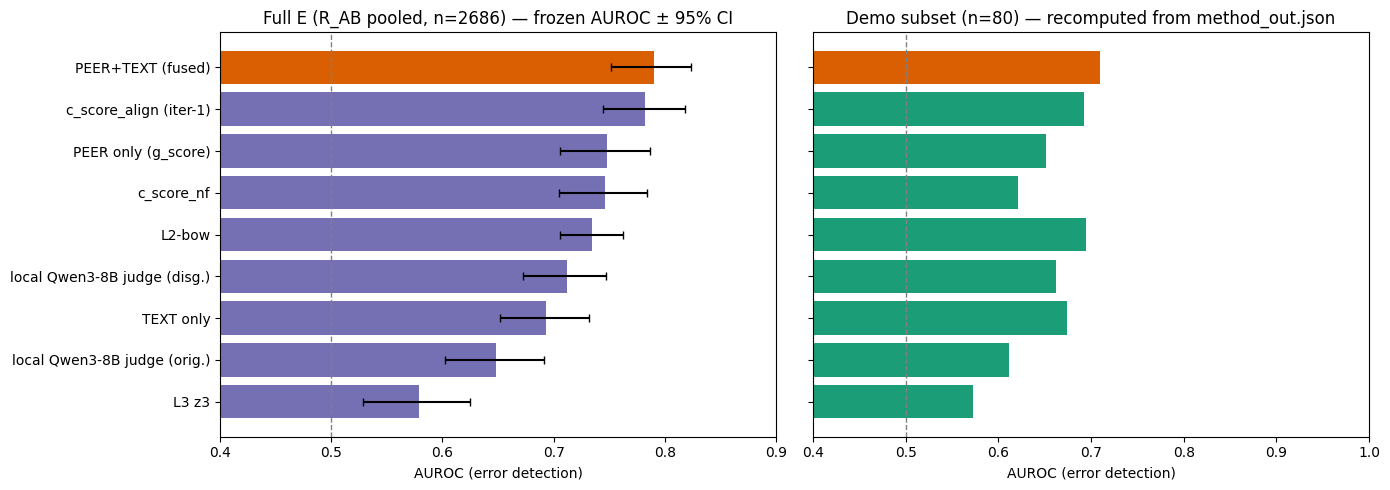

                                                                  text                                                candidate_fol                 system p_peer_text flag signal top_code      label tier
A species of plant that produces flowers, is pollinated by insects or  ∀x (ProducesFlowers(x) ∧ (PollinatedByInsects(x) ∨ Pollinate G1b:meta-llama/llama-3    0.965779    1   PEER      ADD      ERROR    B
A movie can be a box office success if it has high grossing revenue an Movie(x) → (HighGrossingRevenue(x) ∧ PositiveReviews(x, crit G1:meta-llama/llama-3.    0.713875    1   PEER      ADD      ERROR    B
An asteroid is a small rocky body orbiting the sun, a comet is a celes ∀x (Asteroid(x) ↔ (SmallRockyBody(x) ∧ Orbits(x, sun))) ∧ ∀x G2:qwen/qwen3-235b-a22    0.734955    1   PEER      ADD    CORRECT    B
A musical composition typically consisting of multiple movements, ofte ∀x (MusicalComposition(x) ∧ ConsistsOf(x, multipleMovements) G5:google/gemma-3-27b-    0.381126    0   PEER      

In [10]:
out = json.loads((ROOT / "method_out.json").read_text())
ex = out["datasets"][0]["examples"]
meta = out["metadata"]

# ---- 1. frozen full-E headline table ----
NAMES = {"p_peer_text": "PEER+TEXT (fused)", "c_score_align": "c_score_align (iter-1)", "peer_only": "PEER only (g_score)",
         "c_score_nf": "c_score_nf", "p_text": "TEXT only", "l2_bow": "L2-bow", "l3_z3": "L3 z3",
         "judge_local_qwen8b_disg": "local Qwen3-8B judge (disg.)", "judge_local_qwen8b_orig": "local Qwen3-8B judge (orig.)"}
head = meta["headline_auroc_tables"]["R_AB pooled"]
# the judge baselines are scored in the analysis's paired "vs_judge_*" sub-tables (same 2,686 rows), not in the headline table
judge_tab = {j: data["analysis"]["a_tables"]["R_AB pooled"][f"vs_{j}"]["metrics"].get(j) for j in ("judge_local_qwen8b_disg", "judge_local_qwen8b_orig")}
rows = []
for k, lab in NAMES.items():
    m = head["metrics"].get(k) or judge_tab.get(k)
    if m and m.get("auroc") is not None:
        rows.append({"metric": lab, "key": k, "auroc": m["auroc"], "ci_lo": m["ci"][0], "ci_hi": m["ci"][1], "auprc": m.get("auprc")})
full_df = pd.DataFrame(rows).sort_values("auroc", ascending=False)
print(f"Full E, R_AB pooled: n={head['n']} (errors={head['n_error']}, correct={head['n_correct']})")
print(full_df[["metric", "auroc", "ci_lo", "ci_hi", "auprc"]].round(3).to_string(index=False))

print("\nOther frozen headline slices (PEER+TEXT vs c_score_align vs local judge):")
for sl in ["R_AB long (L25+L20+EXC)", "R_A pooled L20+EXC", "R_AB CTRL"]:
    mm = dict(meta["headline_auroc_tables"].get(sl, {}).get("metrics", {}))
    mm.update((data["analysis"]["a_tables"].get(sl, {}).get("vs_judge_local_qwen8b_disg") or {}).get("metrics", {}))
    print(f"  {sl:26s} " + "  ".join(f"{k}={mm[k]['auroc']:.3f}" for k in ("p_peer_text", "c_score_align", "judge_local_qwen8b_disg")
                                          if k in mm and mm[k].get("auroc") is not None))

d = meta["criteria"]["judge_local_qwen8b_disg"]["delta_R_AB"]
print(f"\nDelta PEER+TEXT - local judge (pooled R_AB): {d['delta']:+.3f}  CI [{d['ci'][0]:+.3f}, {d['ci'][1]:+.3f}]  DeLong p={d['delong_p']:.1e}")

# ---- 2. recompute AUROC on the demo rows from the freshly built method_out.json ----
PRED = {"p_peer_text": "predict_peer_text", "c_score_align": "predict_c_score_align", "peer_only": "predict_peer",
        "c_score_nf": "predict_c_score_nf", "p_text": "predict_text", "l2_bow": "predict_l2_bow", "l3_z3": "predict_l3",
        "judge_local_qwen8b_disg": "predict_judge_local_qwen8b_disg", "judge_local_qwen8b_orig": "predict_judge_local_qwen8b_orig"}
lab = [e for e in ex if e["output"] in ("ERROR", "CORRECT") and e["metadata_label_tier"] in ("A", "B")]
y = np.array([1 if e["output"] == "ERROR" else 0 for e in lab])
sub = {}
if len(set(y)) == 2:
    for k, f in PRED.items():
        v = np.array([np.nan if e[f] == "NA" else float(e[f]) for e in lab])
        if np.isnan(v).all():
            continue
        v = np.where(np.isnan(v), np.nanmedian(v), v)
        sub[k] = roc_auc_score(y, v)
print(f"\nDemo subset (tiers A/B): {len(lab)} rows, {int(y.sum())} errors / {int((1 - y).sum())} correct")
full_df["demo_auroc"] = full_df["key"].map(sub)
print(full_df[["metric", "auroc", "demo_auroc"]].round(3).to_string(index=False))

# ---- 3. plots ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
yy = np.arange(len(full_df))[::-1]
axes[0].barh(yy, full_df["auroc"], xerr=[full_df["auroc"] - full_df["ci_lo"], full_df["ci_hi"] - full_df["auroc"]],
             color=["#d95f02" if k == "p_peer_text" else "#7570b3" for k in full_df["key"]], capsize=3)
axes[0].set_yticks(yy); axes[0].set_yticklabels(full_df["metric"])
axes[0].axvline(0.5, color="grey", ls="--", lw=1); axes[0].set_xlim(0.4, 0.9)
axes[0].set_title(f"Full E (R_AB pooled, n={head['n']}) — frozen AUROC ± 95% CI"); axes[0].set_xlabel("AUROC (error detection)")
axes[1].barh(yy, full_df["demo_auroc"].fillna(0), color=["#d95f02" if k == "p_peer_text" else "#1b9e77" for k in full_df["key"]])
axes[1].axvline(0.5, color="grey", ls="--", lw=1); axes[1].set_xlim(0.4, 1.0)
axes[1].set_title(f"Demo subset (n={len(lab)}) — recomputed from method_out.json"); axes[1].set_xlabel("AUROC (error detection)")
plt.tight_layout(); plt.show()

# ---- 4. a few rows: sentence, candidate, fused score, label ----
show = []
for e in ex[:8]:
    i = json.loads(e["input"])
    show.append({"text": i["text"][:70], "candidate_fol": (i["candidate_fol"] or "<empty>")[:60], "system": i["system"][:22],
                 "p_peer_text": e["predict_peer_text"], "flag": e["predict_peer_text_flag"], "signal": e["metadata_fired_signal"],
                 "top_code": e["metadata_top_code"], "label": e["output"], "tier": e["metadata_label_tier"]})
pd.set_option("display.max_colwidth", 80); pd.set_option("display.width", 250)
print(pd.DataFrame(show).to_string(index=False))

# ---- 5. pre-registered prediction outcomes ----
print("\nPre-registered tests (full E):")
for k, v in meta["p_tests"].items():
    if isinstance(v, dict):
        verdict = v.get("verdict") or v.get("outcome") or v.get("status")
        print(f"  {k}: {verdict if verdict is not None else json.dumps(v)[:160]}")
    else:
        print(f"  {k}: {str(v)[:160]}")